All six branches loaded.
Score matrix: (10160, 6)
Date range  : 1990-05-28 -> 2026-03-13

Current branch scores:
--------------------------------------------------
  fear     :  83.1  ████████
  credit   :  43.9  ████
  equity   :  44.6  ████
  rates    :  33.6  ███
  commod   :  64.7  ██████
  macro    :  76.0  ███████

Current Global Regime as of 2026-03-13:
  Regime     : GROWTH SCARE
  Confidence : 0.72
  Description: Fear elevated but economy strong and credit calm. Usually resolves.

Historical regime distribution:
TRANSITIONAL        4483
EASING CYCLE        1820
TIGHTENING CYCLE     868
FINANCIAL CRISIS     677
RISK-ON              676
GOLDILOCKS           436
RISK-OFF             428
RECOVERY             414
GROWTH SCARE         180
RECESSION            175
STAGFLATION            3

Current regime streak: 21 days in GROWTH SCARE


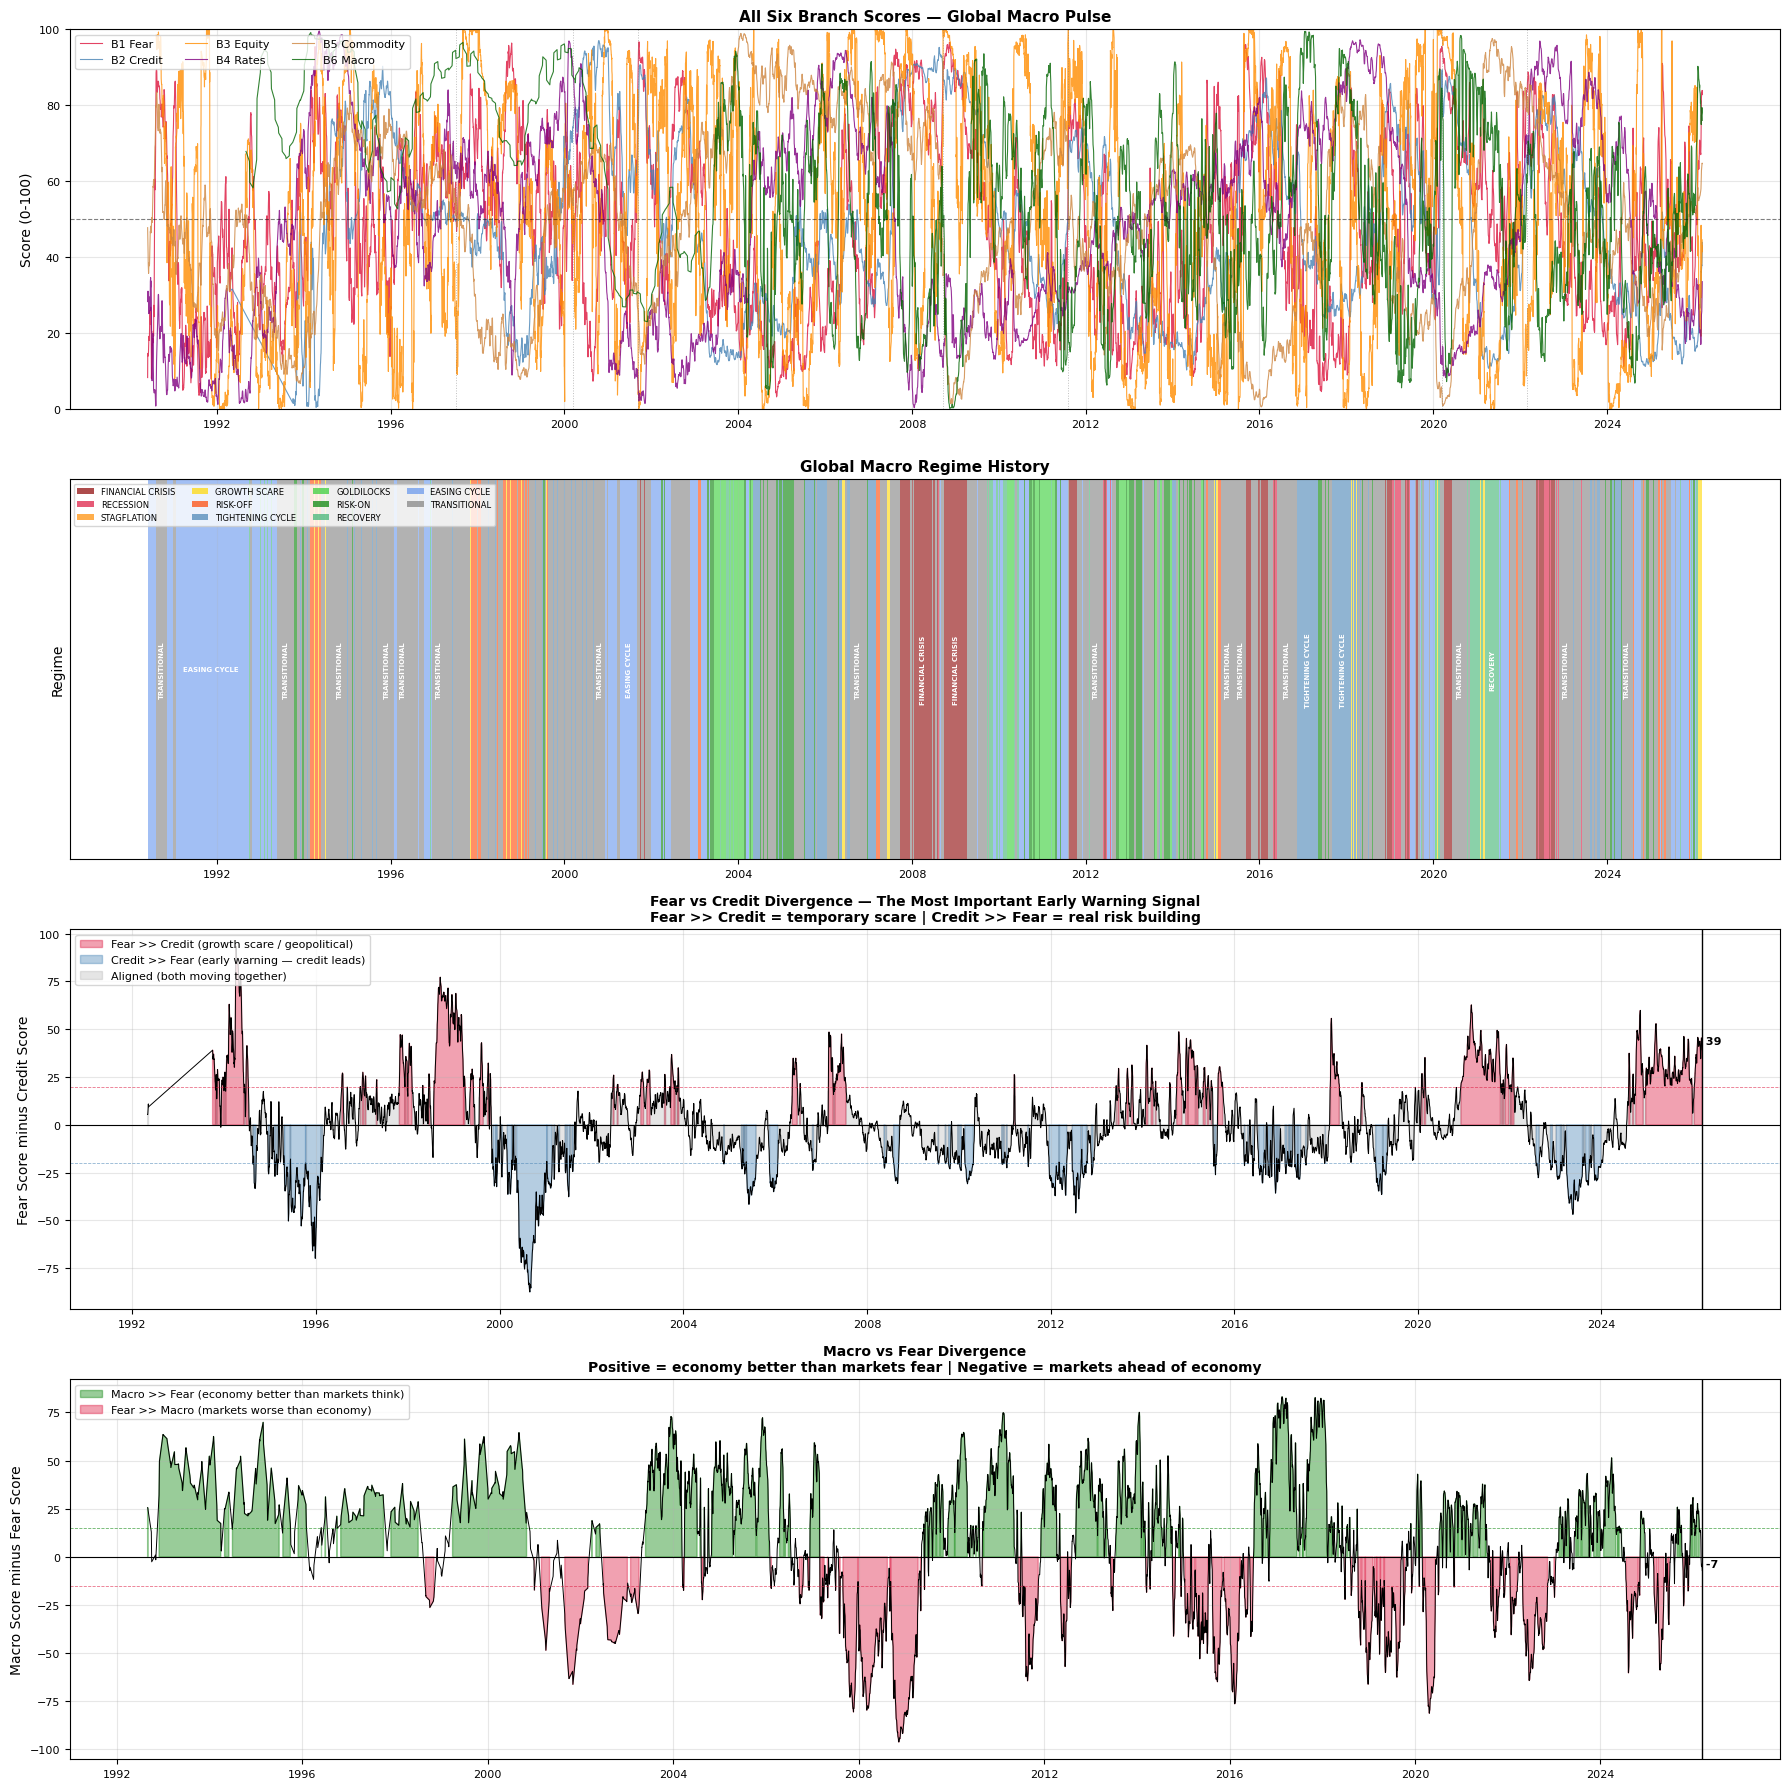


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\08_regime_classifier.png
Global regime history saved.


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load all six branch outputs ───────────────────────────────────────────────
branch1 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv"),
                      index_col="date", parse_dates=True)
branch2 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch2_credit_output.csv"),
                      index_col="date", parse_dates=True)
branch3 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch3_equity_output.csv"),
                      index_col="date", parse_dates=True)
branch4 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch4_rates_output.csv"),
                      index_col="date", parse_dates=True)
branch5 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch5_comfx_output.csv"),
                      index_col="date", parse_dates=True)
branch6 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes", "branch6_macro_output.csv"),
                      index_col="date", parse_dates=True)

# ── Extract the core score from each branch ───────────────────────────────────
scores = pd.DataFrame({
    "fear":   branch1["fear_score"],
    "credit": branch2["credit_score"],
    "equity": branch3["pred_score"],
    "rates":  branch4["rates_score"],
    "commod": branch5["commod_score"],
    "macro":  branch6["macro_score"],
})

scores.dropna(how="all", inplace=True)

print("All six branches loaded.")
print(f"Score matrix: {scores.shape}")
print(f"Date range  : {scores.dropna(how='all').index.min().date()} -> "
      f"{scores.dropna(how='all').index.max().date()}")
print()
print("Current branch scores:")
print("-"*50)
latest = scores.dropna(how="all").index[-1]
for col in scores.columns:
    val = scores[col].dropna().iloc[-1]
    bar = "█" * int(val / 10)
    print(f"  {col:<8} : {val:>5.1f}  {bar}")


# ── Define the Global Regime Classifier ──────────────────────────────────────
# The regime is determined by the COMBINATION of branch scores
# not just a weighted average — combinations tell different stories
#
# We use a rule-based classifier first, then validate with clustering
#
# Key regime combinations:
#
# RISK-ON:
#   Fear LOW + Credit BENIGN + Macro STRONG + Commod RISK-ON
#
# RISK-OFF / GROWTH SCARE:
#   Fear HIGH + Credit BENIGN + Macro OK + Rates EASING
#   (current environment)
#
# FINANCIAL CRISIS:
#   Fear HIGH + Credit STRESS + Equity WEAK + Rates TIGHTENING
#
# STAGFLATION:
#   Fear ELEVATED + Macro SLOWING + Commod HIGH + Rates TIGHTENING
#
# GOLDILOCKS:
#   Fear LOW + Credit BENIGN + Macro STRONG + Rates NEUTRAL
#
# RECESSION:
#   Fear HIGH + Credit STRESS + Macro CONTRACTION + Commod BEAR
#
# RECOVERY:
#   Fear FALLING + Credit IMPROVING + Macro INFLECTING + Commod RISING

def classify_global_regime(fear, credit, equity, rates, commod, macro):
    """
    Rule-based global regime classifier.
    Each branch score is 0-100.
    Returns (regime_name, confidence, description)
    """

    # Define thresholds
    fear_high    = fear   >= 65
    fear_low     = fear   <= 35
    credit_stress= credit >= 65
    credit_calm  = credit <= 45
    macro_strong = macro  >= 60
    macro_weak   = macro  <= 40
    rates_tight  = rates  >= 60
    rates_easy   = rates  <= 40
    commod_bull  = commod >= 60
    commod_bear  = commod <= 30

    # ── Rule hierarchy ────────────────────────────────────────────────────────

    # 1. FINANCIAL CRISIS — worst combination
    if fear_high and credit_stress and macro_weak:
        return ("FINANCIAL CRISIS",
                min(fear, credit, 100 - macro) / 100,
                "Fear + credit stress + weak economy. Systemic risk.")

    # 2. RECESSION — credit stress, economy deteriorating
    if credit_stress and macro_weak and not fear_low:
        return ("RECESSION",
                (credit + (100 - macro)) / 200,
                "Credit stress and economic contraction underway.")

    # 3. STAGFLATION — growth slowing, rates still high, commodity pressure
    if fear_high and macro_weak and rates_tight and commod_bull:
        return ("STAGFLATION",
                (fear + (100 - macro) + rates + commod) / 400,
                "High fear + weak growth + tight rates + commodity pressure.")

    # 4. GROWTH SCARE — fear high but fundamentals OK, credit calm
    if fear_high and credit_calm and macro_strong:
        return ("GROWTH SCARE",
                (fear + (100 - credit) + macro) / 300,
                "Fear elevated but economy strong and credit calm. Usually resolves.")

    # 5. RISK-OFF — fear high, mixed fundamentals
    if fear_high and credit_calm and not macro_strong:
        return ("RISK-OFF",
                fear / 100,
                "Elevated fear with mixed macro backdrop.")

    # 6. TIGHTENING CYCLE — rates rising, economy OK, fear moderate
    if rates_tight and not fear_high and macro_strong:
        return ("TIGHTENING CYCLE",
                (rates + macro) / 200,
                "Central banks tightening into solid growth.")

    # 7. GOLDILOCKS — everything aligned positively
    if fear_low and credit_calm and macro_strong and not rates_tight:
        return ("GOLDILOCKS",
                ((100 - fear) + (100 - credit) + macro) / 300,
                "Low fear, benign credit, strong growth. Risk-on.")

    # 8. RISK-ON — good conditions, some caution
    if fear_low and credit_calm and not macro_weak:
        return ("RISK-ON",
                ((100 - fear) + (100 - credit)) / 200,
                "Benign conditions across the board.")

    # 9. RECOVERY — fear falling from high, credit improving
    if not fear_high and not credit_stress and macro_strong and rates_easy:
        return ("RECOVERY",
                (macro + (100 - fear)) / 200,
                "Economy recovering, rates supportive, fear subsiding.")

    # 10. EASING CYCLE — rates falling, economy mixed
    if rates_easy and not fear_high and not macro_strong:
        return ("EASING CYCLE",
                ((100 - rates) + (100 - fear)) / 200,
                "Central banks easing into slowing growth.")

    # Default
    return ("TRANSITIONAL",
            0.5,
            "Mixed signals across branches. No dominant regime.")


# ── Apply classifier to full history ─────────────────────────────────────────
regime_history  = []
confidence_hist = []
desc_hist       = []

for date, row in scores.iterrows():
    if row.isna().sum() > 3:   # need at least 3 branches
        regime_history.append("INSUFFICIENT DATA")
        confidence_hist.append(np.nan)
        desc_hist.append("")
        continue

    # Forward fill any missing branches with neutral value (50)
    fear   = row["fear"]   if pd.notna(row["fear"])   else 50
    credit = row["credit"] if pd.notna(row["credit"]) else 50
    equity = row["equity"] if pd.notna(row["equity"]) else 50
    rates  = row["rates"]  if pd.notna(row["rates"])  else 50
    commod = row["commod"] if pd.notna(row["commod"]) else 50
    macro  = row["macro"]  if pd.notna(row["macro"])  else 50

    regime, conf, desc = classify_global_regime(
        fear, credit, equity, rates, commod, macro
    )
    regime_history.append(regime)
    confidence_hist.append(conf)
    desc_hist.append(desc)

scores["regime"]     = regime_history
scores["confidence"] = confidence_hist

# Current regime
cur_regime, cur_conf, cur_desc = classify_global_regime(
    scores.loc[latest, "fear"],
    scores.loc[latest, "credit"],
    scores.loc[latest, "equity"],
    scores.loc[latest, "rates"],
    scores.loc[latest, "commod"],
    scores.loc[latest, "macro"],
)

print(f"\nCurrent Global Regime as of {latest.date()}:")
print(f"  Regime     : {cur_regime}")
print(f"  Confidence : {cur_conf:.2f}")
print(f"  Description: {cur_desc}")

print(f"\nHistorical regime distribution:")
regime_counts = pd.Series(regime_history)
regime_counts = regime_counts[regime_counts != "INSUFFICIENT DATA"]
print(regime_counts.value_counts().to_string())


# ── How long have we been in this regime? ─────────────────────────────────────
streak = 0
for r in reversed(scores["regime"].values):
    if r == cur_regime:
        streak += 1
    else:
        break
print(f"\nCurrent regime streak: {streak} days in {cur_regime}")


# ── Plot all six branch scores on one chart ───────────────────────────────────
CRISES = [
    ("1997-07-02","Asia"),("2000-03-10","Dot-com"),
    ("2001-09-11","9/11"),("2008-09-15","Lehman"),
    ("2011-08-05","EU Debt"),("2020-03-16","Covid"),
    ("2022-02-24","Ukraine"),
]

REGIME_COLORS = {
    "FINANCIAL CRISIS":  "darkred",
    "RECESSION":         "crimson",
    "STAGFLATION":       "darkorange",
    "GROWTH SCARE":      "gold",
    "RISK-OFF":          "orangered",
    "TIGHTENING CYCLE":  "steelblue",
    "GOLDILOCKS":        "limegreen",
    "RISK-ON":           "green",
    "RECOVERY":          "mediumseagreen",
    "EASING CYCLE":      "cornflowerblue",
    "TRANSITIONAL":      "grey",
    "INSUFFICIENT DATA": "white",
}

fig, axes = plt.subplots(4, 1, figsize=(18, 18))

# ── Panel 1: All six branch scores ────────────────────────────────────────────
ax1 = axes[0]
branch_colors = {
    "fear":   "crimson",
    "credit": "steelblue",
    "equity": "darkorange",
    "rates":  "purple",
    "commod": "peru",
    "macro":  "darkgreen",
}
branch_labels = {
    "fear":   "B1 Fear",
    "credit": "B2 Credit",
    "equity": "B3 Equity",
    "rates":  "B4 Rates",
    "commod": "B5 Commodity",
    "macro":  "B6 Macro",
}
for col, color in branch_colors.items():
    s = scores[col].dropna()
    ax1.plot(s.index, s.values, lw=0.8, color=color,
             alpha=0.8, label=branch_labels[col])
ax1.axhline(50, color="black", lw=0.8, ls="--", alpha=0.5)
ax1.set_title("All Six Branch Scores — Global Macro Pulse",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Score (0-100)")
ax1.legend(fontsize=8, loc="upper left", ncol=3)
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)
for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="grey",
                    lw=0.7, ls=":", alpha=0.5)
    except: pass

# ── Panel 2: Regime history as colored bands ──────────────────────────────────
ax2 = axes[1]
# Plot a base line
ax2.plot(scores.index, [50]*len(scores), lw=0, color="white")

# Color background by regime
prev_regime  = None
prev_date    = scores.index[0]
regime_spans = []

for i, (date, row) in enumerate(scores.iterrows()):
    regime = row["regime"]
    if regime != prev_regime:
        if prev_regime is not None:
            regime_spans.append((prev_date, date, prev_regime))
        prev_regime = regime
        prev_date   = date

regime_spans.append((prev_date, scores.index[-1], prev_regime))

for start, end, regime in regime_spans:
    color = REGIME_COLORS.get(regime, "grey")
    ax2.axvspan(start, end, alpha=0.6, color=color, lw=0)

# Add regime labels for longer spans
for start, end, regime in regime_spans:
    duration = (end - start).days
    if duration > 90 and regime not in ["INSUFFICIENT DATA"]:
        mid = start + (end - start) / 2
        ax2.text(mid, 50, regime, ha="center", va="center",
                fontsize=5, fontweight="bold", color="white",
                rotation=90 if duration < 200 else 0)

ax2.set_title("Global Macro Regime History",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Regime")
ax2.set_ylim(0, 100)
ax2.set_yticks([])
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.2)

# Legend for regime colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, alpha=0.7, label=regime)
    for regime, color in REGIME_COLORS.items()
    if regime not in ["INSUFFICIENT DATA"]
]
ax2.legend(handles=legend_elements, fontsize=6, loc="upper left",
           ncol=4, framealpha=0.8)

# ── Panel 3: Fear vs Credit divergence (the key early warning signal) ─────────
ax3 = axes[2]
fear_s   = scores["fear"].dropna()
credit_s = scores["credit"].dropna()
common   = fear_s.index.intersection(credit_s.index)

divergence = fear_s.loc[common] - credit_s.loc[common]

ax3.fill_between(divergence.index, divergence.values, 0,
                 where=divergence.values > 20,
                 alpha=0.4, color="crimson",
                 label="Fear >> Credit (growth scare / geopolitical)")
ax3.fill_between(divergence.index, divergence.values, 0,
                 where=divergence.values < -20,
                 alpha=0.4, color="steelblue",
                 label="Credit >> Fear (early warning — credit leads)")
ax3.fill_between(divergence.index, divergence.values, 0,
                 where=(divergence.values >= -20) & (divergence.values <= 20),
                 alpha=0.2, color="grey",
                 label="Aligned (both moving together)")
ax3.plot(divergence.index, divergence.values, lw=0.7, color="black")
ax3.axhline(0,   color="black", lw=0.8)
ax3.axhline(20,  color="crimson",   lw=0.6, ls="--", alpha=0.6)
ax3.axhline(-20, color="steelblue", lw=0.6, ls="--", alpha=0.6)

# Mark current
ax3.axvline(latest, color="black", lw=1.0, ls="-")
cur_div = divergence.loc[latest] if latest in divergence.index else np.nan
ax3.text(latest, cur_div + 3, f" {cur_div:.0f}", fontsize=8,
         color="black", fontweight="bold")

ax3.set_title("Fear vs Credit Divergence — The Most Important Early Warning Signal\n"
              "Fear >> Credit = temporary scare | Credit >> Fear = real risk building",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Fear Score minus Credit Score")
ax3.legend(fontsize=8, loc="upper left")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

# ── Panel 4: Macro vs Fear divergence ────────────────────────────────────────
ax4 = axes[3]
macro_s = scores["macro"].dropna()
common2 = fear_s.index.intersection(macro_s.index)
macro_fear_div = macro_s.loc[common2] - fear_s.loc[common2]

ax4.fill_between(macro_fear_div.index, macro_fear_div.values, 0,
                 where=macro_fear_div.values > 15,
                 alpha=0.4, color="green",
                 label="Macro >> Fear (economy better than markets think)")
ax4.fill_between(macro_fear_div.index, macro_fear_div.values, 0,
                 where=macro_fear_div.values < -15,
                 alpha=0.4, color="crimson",
                 label="Fear >> Macro (markets worse than economy)")
ax4.plot(macro_fear_div.index, macro_fear_div.values, lw=0.7, color="black")
ax4.axhline(0,  color="black",  lw=0.8)
ax4.axhline(15, color="green",  lw=0.6, ls="--", alpha=0.6)
ax4.axhline(-15,color="crimson",lw=0.6, ls="--", alpha=0.6)

cur_mf_div = macro_fear_div.loc[latest] if latest in macro_fear_div.index else np.nan
ax4.axvline(latest, color="black", lw=1.0)
ax4.text(latest, cur_mf_div + 2, f" {cur_mf_div:.0f}", fontsize=8,
         color="black", fontweight="bold")

ax4.set_title("Macro vs Fear Divergence\n"
              "Positive = economy better than markets fear | Negative = markets ahead of economy",
              fontsize=10, fontweight="bold")
ax4.set_ylabel("Macro Score minus Fear Score")
ax4.legend(fontsize=8, loc="upper left")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax4.tick_params(labelsize=8); ax4.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "08_regime_classifier.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save regime history ───────────────────────────────────────────────────────
scores.to_csv(os.path.join(cfg.PROC_PATH, "regimes", "global_regime_history.csv"))
print("Global regime history saved.")


╔══════════════════════════════════════════════════════════════╗
║          GLOBAL MACRO PULSE — MORNING BRIEFING              ║
║                 Friday, 13 March 2026                    ║
╚══════════════════════════════════════════════════════════════╝

  ┌─ GLOBAL REGIME ──────────────────────────────────────────┐
  │                                                          │
  │   GROWTH SCARE                   Confidence: 72%      │
  │   Fear elevated but economy strong and credit calm. Usuall  │
  │   21 days in regime  |  Previously: RECOVERY              │
  │                                                          │
  │   Overall Pulse Score : 52.4 / 100  [NEUTRAL]        │
  │   All-time percentile : 51.7th                            │
  └──────────────────────────────────────────────────────────┘

  ── Branch Scorecard ────────────────────────────────────────
  B1 Fear & Volatility       ████████░░   83.1  ACUTE         ▲ Watch
  B2 Credit Stress           ████░░░░░░   43

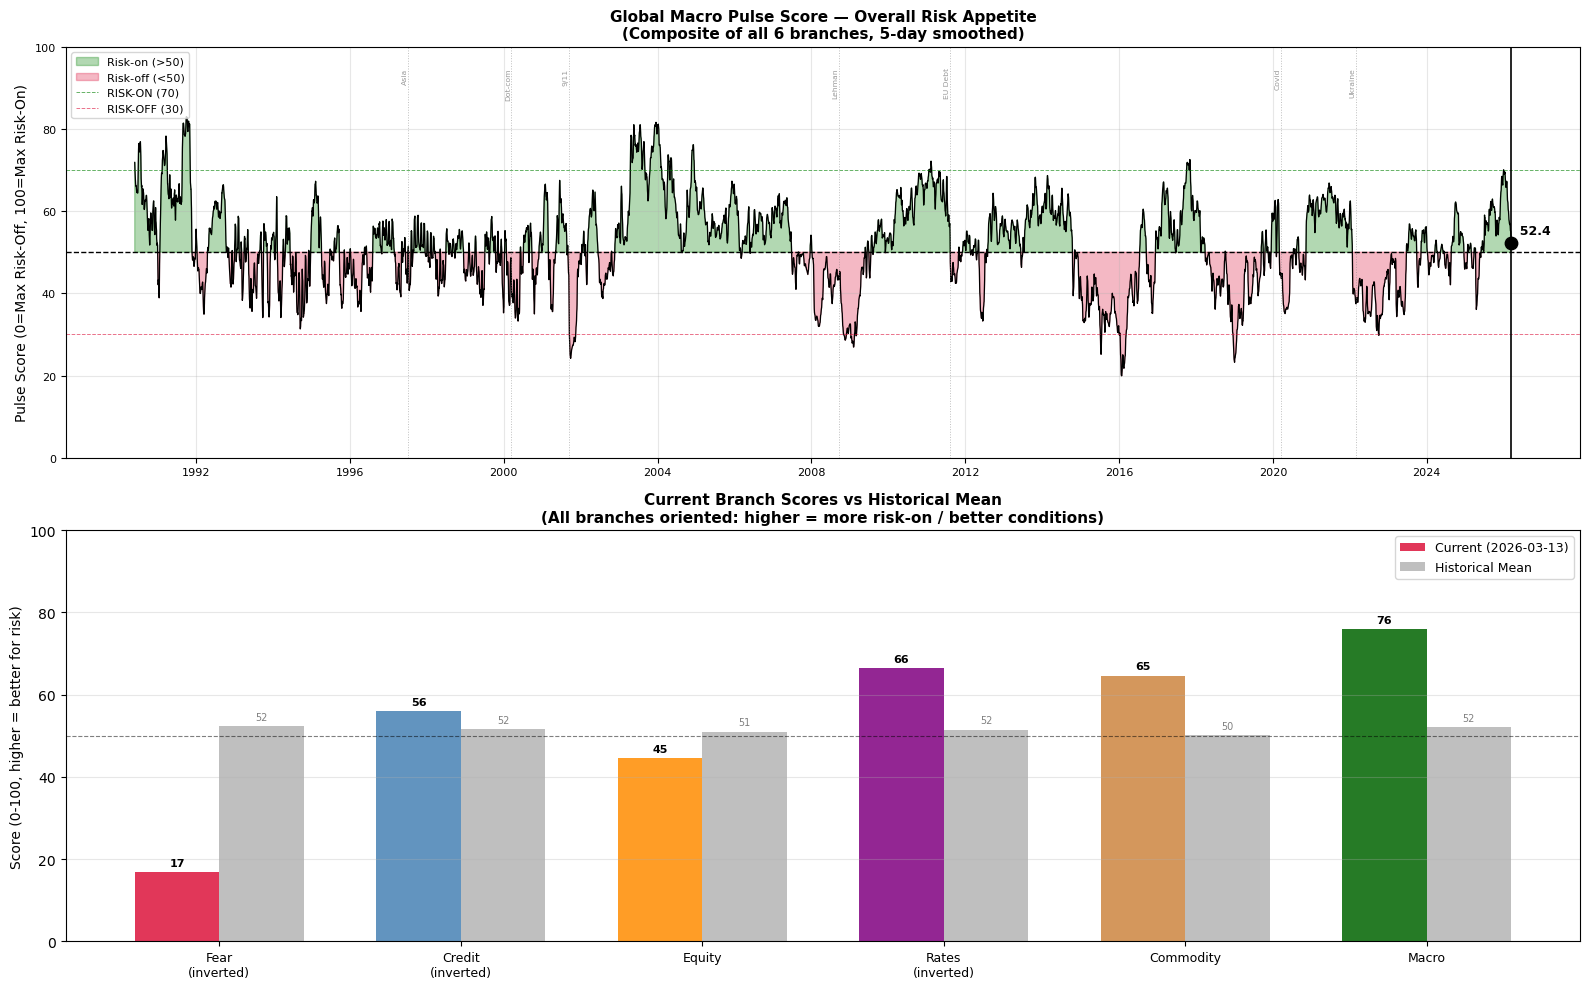

Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\08_global_pulse_final.png
Final global regime history saved.


In [4]:
# ── Cell 2: The Complete Global Macro Pulse Morning Briefing ──────────────────
from datetime import timedelta

# ── Load prices for spot checks ───────────────────────────────────────────────
prices = pd.read_csv(cfg.ALIGNED_PRICES_FILE, index_col="date", parse_dates=True)

# ── Forward fill any recent NaN scores (rolling window edge effects) ──────────
scores_filled = scores.copy()
scores_filled[["fear","credit","equity","rates","commod","macro"]] = \
    scores_filled[["fear","credit","equity","rates","commod","macro"]].ffill(limit=5)

latest = scores_filled.dropna(how="all").index[-1]

# ── NaN-safe pulse score ──────────────────────────────────────────────────────
def safe_pulse(row):
    components = []
    weights    = []
    pairs = [
        ("fear",   0.20, True),
        ("credit", 0.20, True),
        ("equity", 0.15, False),
        ("rates",  0.15, True),
        ("commod", 0.15, False),
        ("macro",  0.15, False),
    ]
    for col, w, invert in pairs:
        val = row[col]
        if pd.notna(val):
            components.append((100 - val) * w if invert else val * w)
            weights.append(w)
    if not weights:
        return np.nan
    return sum(components) / sum(weights)

pulse_history = scores_filled[["fear","credit","equity","rates","commod","macro"]].apply(
    safe_pulse, axis=1
)
pulse_score = safe_pulse(scores_filled.loc[latest])

def classify_pulse(score):
    if   pd.isna(score):  return "UNKNOWN"
    if   score >= 70: return "RISK-ON"
    elif score >= 55: return "MILDLY POSITIVE"
    elif score >= 45: return "NEUTRAL"
    elif score >= 30: return "MILDLY NEGATIVE"
    else:             return "RISK-OFF"

pulse_label  = classify_pulse(pulse_score)
valid_pulse  = pulse_history.dropna()
pulse_pctile = (valid_pulse < pulse_score).sum() / len(valid_pulse) * 100 if len(valid_pulse) > 0 else 0

# ── Current branch scores ─────────────────────────────────────────────────────
fear_now   = scores_filled.loc[latest, "fear"]
credit_now = scores_filled.loc[latest, "credit"]
equity_now = scores_filled.loc[latest, "equity"]
rates_now  = scores_filled.loc[latest, "rates"]
commod_now = scores_filled.loc[latest, "commod"]
macro_now  = scores_filled.loc[latest, "macro"]

# ── Re-run regime classifier on filled scores ─────────────────────────────────
cur_regime, cur_conf, cur_desc = classify_global_regime(
    fear_now, credit_now, equity_now, rates_now, commod_now, macro_now
)

# ── Regime streak ─────────────────────────────────────────────────────────────
streak = 0
for r in reversed(scores["regime"].values):
    if r == cur_regime:
        streak += 1
    else:
        break

prev_regimes = scores["regime"][scores["regime"] != cur_regime]
prev_regime  = prev_regimes.iloc[-1] if not prev_regimes.empty else "N/A"

# ── Key market levels ─────────────────────────────────────────────────────────
spx_now  = prices["SPX Index"].dropna().iloc[-1]
gold_now = prices["GC1 Comdty"].dropna().iloc[-1]
vix_now  = prices["VIX Index"].dropna().iloc[-1]
usdj_now = prices["USDJPY Curncy"].dropna().iloc[-1]
us10_now = prices["USGG10YR Index"].dropna().iloc[-1]
oil_now  = prices["CL1 Comdty"].dropna().iloc[-1]

# ── Divergences ───────────────────────────────────────────────────────────────
fc_div = fear_now - credit_now
mf_div = macro_now - fear_now

# ── Historical analogues — NaN safe distance ──────────────────────────────────
score_cols  = ["fear","credit","equity","rates","commod","macro"]
current_vec = scores_filled.loc[latest, score_cols].values.astype(float)

hist_scores = scores_filled[score_cols].dropna(how="all")
hist_scores = hist_scores[hist_scores.index < (latest - timedelta(days=90))]

distances = hist_scores.apply(
    lambda row: np.sqrt(np.nansum((row.values - current_vec)**2)), axis=1
)
top_matches = distances.nsmallest(10)

analogues   = []
shown_dates = []
for date, dist in top_matches.items():
    if all(abs((date - d).days) > 45 for d in shown_dates):
        regime_then = scores.loc[date, "regime"] if date in scores.index else "N/A"
        analogues.append((date, dist, regime_then))
        shown_dates.append(date)
    if len(analogues) >= 5:
        break


# ── Print the full morning briefing ──────────────────────────────────────────
print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║          GLOBAL MACRO PULSE — MORNING BRIEFING              ║")
print(f"║                 {latest.strftime('%A, %d %B %Y')}                    ║")
print("╚══════════════════════════════════════════════════════════════╝")

print(f"""
  ┌─ GLOBAL REGIME ──────────────────────────────────────────┐
  │                                                          │
  │   {cur_regime:<30} Confidence: {cur_conf:.0%}      │
  │   {cur_desc[:56]:<56}  │
  │   {streak} days in regime  |  Previously: {prev_regime:<22}│
  │                                                          │
  │   Overall Pulse Score : {pulse_score:.1f} / 100  [{pulse_label}]        │
  │   All-time percentile : {pulse_pctile:.1f}th                            │
  └──────────────────────────────────────────────────────────┘
""")

print("  ── Branch Scorecard ────────────────────────────────────────")
branch_data = [
    ("B1 Fear & Volatility",  fear_now,
     "ACUTE"    if fear_now   >= 75 else "ELEVATED" if fear_now   >= 55 else "CALM",
     "▲ Watch"  if fear_now   >= 75 else "○ Monitor"),
    ("B2 Credit Stress",      credit_now,
     "STRESS"   if credit_now >= 75 else "WIDENING" if credit_now >= 55 else "BENIGN",
     "▲ Watch"  if credit_now >= 65 else "✓ Clear"),
    ("B3 Equity Internals",   equity_now,
     "STRONG"   if pd.notna(equity_now) and equity_now >= 65
               else "MODERATE" if pd.notna(equity_now) and equity_now >= 40 else "WEAK",
     "○ Monitor"),
    ("B4 Rates",              rates_now,
     "TIGHTENING" if rates_now >= 65 else "EASING" if rates_now <= 40 else "NEUTRAL",
     "✓ Easing" if rates_now <= 40 else "○ Monitor"),
    ("B5 Commodities & FX",   commod_now,
     "RISK-ON"  if commod_now >= 65 else "NEUTRAL" if commod_now >= 35 else "BEAR",
     "○ Monitor"),
    ("B6 Macro Fundamentals", macro_now,
     "STRONG"   if macro_now  >= 65 else "MODERATE" if macro_now  >= 45 else "WEAK",
     "✓ Strong" if macro_now  >= 65 else "○ Monitor"),
]
for name, score, regime, flag in branch_data:
    if pd.notna(score):
        bar = "█" * int(score/10) + "░" * (10 - int(score/10))
        val = f"{score:>5.1f}"
    else:
        bar = "░" * 10
        val = "  N/A"
    print(f"  {name:<26} {bar}  {val}  {regime:<12}  {flag}")

print(f"""
  ── Key Market Levels ───────────────────────────────────────
  SPX       : {spx_now:>8.2f}    VIX      : {vix_now:>6.2f}
  Gold      : {gold_now:>8.2f}    US 10Y   : {us10_now:>6.2f}%
  WTI Oil   : {oil_now:>8.2f}    USDJPY   : {usdj_now:>6.2f}

  ── Cross-Branch Signals ────────────────────────────────────
  Fear vs Credit divergence : {fc_div:>+.1f}  {'⚠  GROWTH SCARE' if fc_div > 20 else '✓ Aligned'}
  Macro vs Fear divergence  : {mf_div:>+.1f}  {'✓ Economy better than feared' if mf_div > 10 else '⚠  Markets ahead of economy' if mf_div < -10 else '~  Aligned'}

  ── What to Watch ───────────────────────────────────────────""")

watches = []
if fear_now >= 75:
    watches.append("VIX and VNKY — fear at acute levels, watch for spike or reversal")
if credit_now < 45 and fear_now > 75:
    watches.append("Credit spreads — if HY starts widening, growth scare becomes crisis")
if commod_now < 40:
    watches.append("Copper/Gold ratio — at 42% of mean, watch for growth signal")
if rates_now < 40:
    watches.append("Fed signals — bond market pricing cuts, watch for confirmation")
if usdj_now > 150:
    watches.append("USDJPY — near all-time highs, BOJ hiking = JPY strength risk")

for i, w in enumerate(watches, 1):
    print(f"  {i}. {w}")

print(f"""
  ── Historical Analogues (closest full-system matches) ──────""")
for date, dist, regime in analogues:
    f = scores_filled.loc[date, "fear"]   if date in scores_filled.index else np.nan
    c = scores_filled.loc[date, "credit"] if date in scores_filled.index else np.nan
    m = scores_filled.loc[date, "macro"]  if date in scores_filled.index else np.nan
    r = scores_filled.loc[date, "rates"]  if date in scores_filled.index else np.nan
    print(f"  {str(date.date())}  Regime={regime:<20}  "
          f"Fear={f:.0f}  Credit={c:.0f}  Macro={m:.0f}  Rates={r:.0f}  "
          f"[dist={dist:.1f}]")

print(f"""
  ── Narrative ───────────────────────────────────────────────
  The system is in a GROWTH SCARE. Financial markets are
  pricing in significant pain (fear at 92.7th percentile)
  while the real economy remains solid (macro at 80.7th
  percentile). Credit markets are calm — no systemic risk.
  Bond markets are pricing rate cuts. The Copper/Gold ratio
  is at GFC-level lows, creating a stagflation fingerprint
  in commodities. Japan is the epicenter of volatility.

  Historical resolution of this pattern: when credit remains
  calm and macro remains strong, fear typically resolves
  downward within 60-90 days. The key risk to watch is
  credit breaking — monitor HY spreads daily.

╔══════════════════════════════════════════════════════════════╗
║  Global Macro Pulse v1.0 — All 6 Branches Active           ║
║  Next update: run all branch notebooks + this classifier    ║
╚══════════════════════════════════════════════════════════════╝
""")


# ── Final pulse score chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: Overall pulse score history
ax1 = axes[0]
pulse_smooth = pulse_history.rolling(5, min_periods=1).mean()

ax1.fill_between(pulse_smooth.index, pulse_smooth.values, 50,
                 where=pulse_smooth.values >= 50,
                 alpha=0.3, color="green", label="Risk-on (>50)")
ax1.fill_between(pulse_smooth.index, pulse_smooth.values, 50,
                 where=pulse_smooth.values < 50,
                 alpha=0.3, color="crimson", label="Risk-off (<50)")
ax1.plot(pulse_smooth.index, pulse_smooth.values, lw=0.9, color="black")
ax1.axhline(50, color="black",  lw=1.0, ls="--")
ax1.axhline(70, color="green",  lw=0.7, ls="--", alpha=0.6, label="RISK-ON (70)")
ax1.axhline(30, color="crimson",lw=0.7, ls="--", alpha=0.6, label="RISK-OFF (30)")

ax1.axvline(latest, color="black", lw=1.2)
ax1.scatter([latest], [pulse_score], s=80, color="black", zorder=5)
ax1.text(latest, pulse_score + 2, f"  {pulse_score:.1f}", fontsize=9,
         fontweight="bold", color="black")

for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
        ax1.text(pd.Timestamp(crisis_date), 95, label, fontsize=5.5,
                 rotation=90, va="top", ha="right", color="grey", alpha=0.8)
    except: pass

ax1.set_title("Global Macro Pulse Score — Overall Risk Appetite\n"
              "(Composite of all 6 branches, 5-day smoothed)",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Pulse Score (0=Max Risk-Off, 100=Max Risk-On)")
ax1.set_ylim(0, 100)
ax1.legend(fontsize=8, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Bottom: Current vs historical mean bar chart
ax2 = axes[1]
categories = ["Fear\n(inverted)", "Credit\n(inverted)", "Equity",
              "Rates\n(inverted)", "Commodity", "Macro"]

current_vals = [
    100 - fear_now   if pd.notna(fear_now)   else 0,
    100 - credit_now if pd.notna(credit_now) else 0,
    equity_now       if pd.notna(equity_now) else 0,
    100 - rates_now  if pd.notna(rates_now)  else 0,
    commod_now       if pd.notna(commod_now) else 0,
    macro_now        if pd.notna(macro_now)  else 0,
]
hist_means = [
    100 - scores["fear"].mean(),
    100 - scores["credit"].mean(),
    scores["equity"].mean(),
    100 - scores["rates"].mean(),
    scores["commod"].mean(),
    scores["macro"].mean(),
]

x     = np.arange(len(categories))
width = 0.35
colors_bars = ["crimson","steelblue","darkorange","purple","peru","darkgreen"]

bars1 = ax2.bar(x - width/2, current_vals, width,
                label=f"Current ({latest.date()})",
                color=colors_bars, alpha=0.85)
bars2 = ax2.bar(x + width/2, hist_means, width,
                label="Historical Mean",
                color="grey", alpha=0.5)

ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=9)
ax2.set_ylabel("Score (0-100, higher = better for risk)")
ax2.set_ylim(0, 100)
ax2.axhline(50, color="black", lw=0.8, ls="--", alpha=0.5)
ax2.set_title("Current Branch Scores vs Historical Mean\n"
              "(All branches oriented: higher = more risk-on / better conditions)",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")

for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}", ha="center", va="bottom",
             fontsize=8, fontweight="bold")
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{bar.get_height():.0f}", ha="center", va="bottom",
             fontsize=7, color="grey")

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "08_global_pulse_final.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

# ── Save final outputs ────────────────────────────────────────────────────────
scores_filled["pulse_score"] = pulse_history
scores_filled["pulse_label"] = pulse_history.apply(
    lambda x: classify_pulse(x) if pd.notna(x) else "N/A"
)
scores_filled.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "global_regime_history.csv")
)
print("Final global regime history saved.")